['.config', '.ipynb_checkpoints', 'Churn_Modelling.csv', 'sample_data']
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  

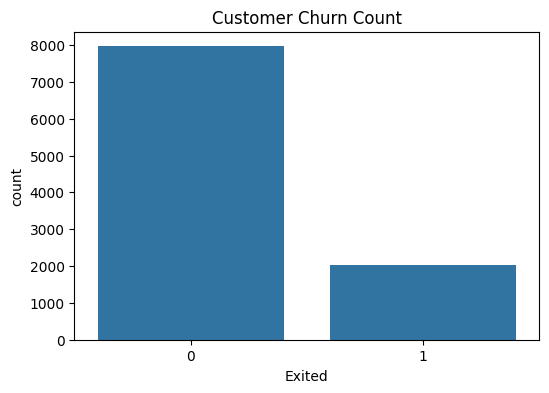

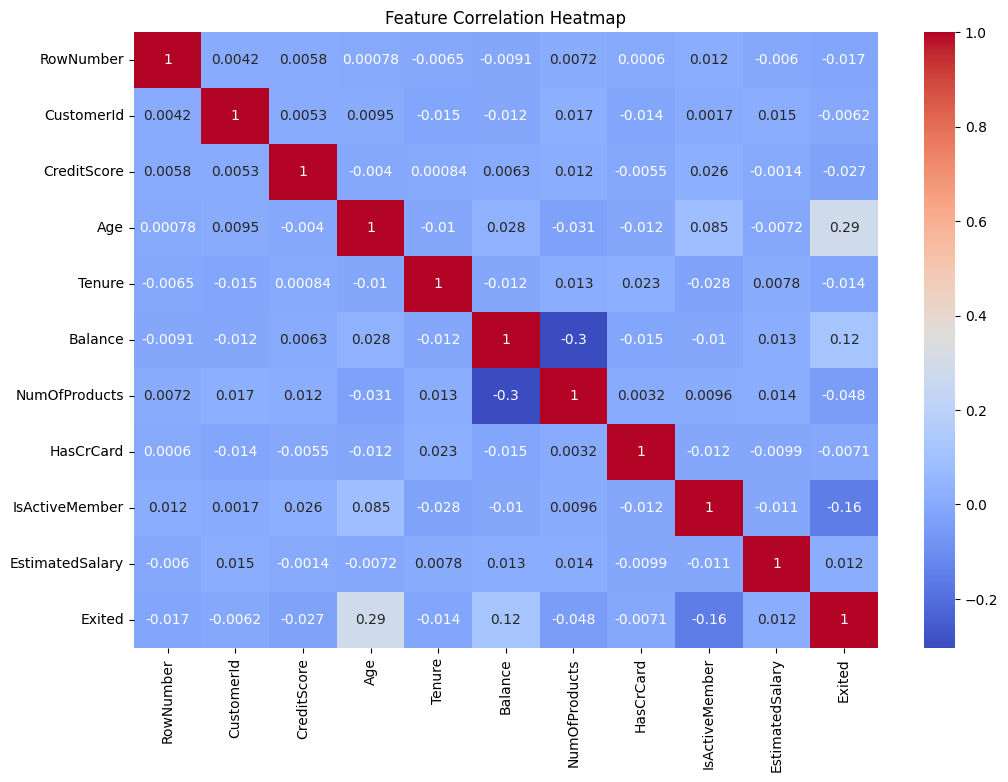

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  
(8000, 10)
(2000, 10)
Training: Logistic Regression
Accuracy: 0.805
Precision: 0.5858585858585859
Recall: 0.14250614250614252
F1 Score: 0.22924901185770752
              precision    recall  f1-score   suppo

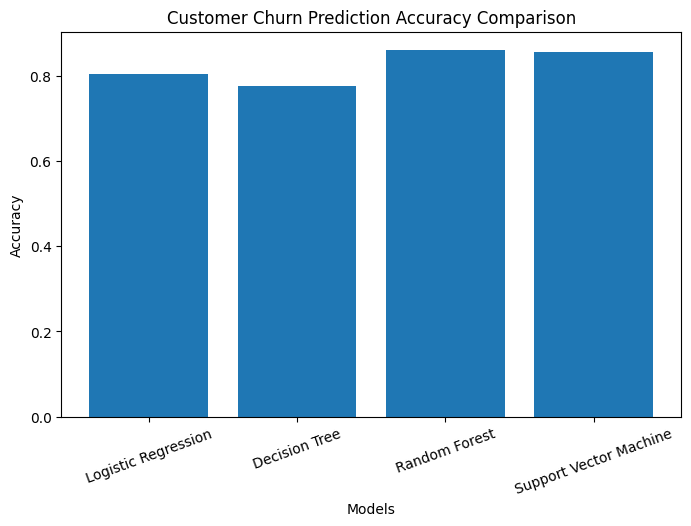

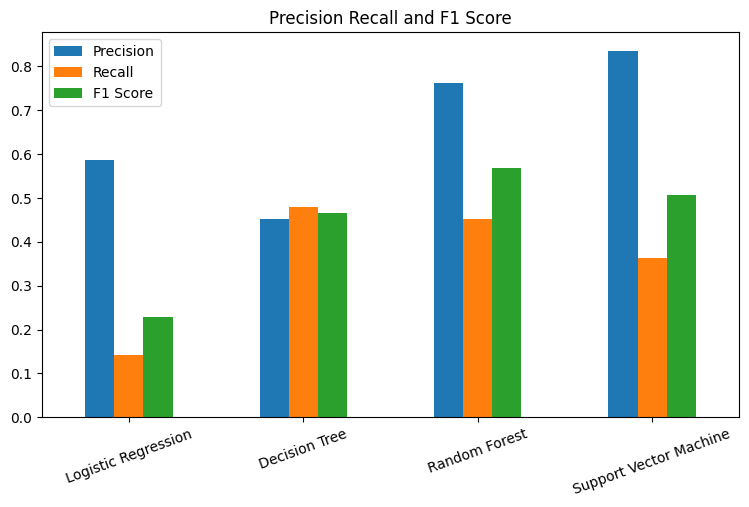

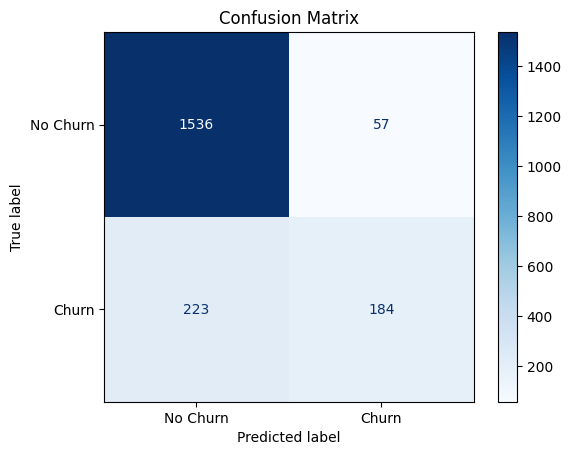

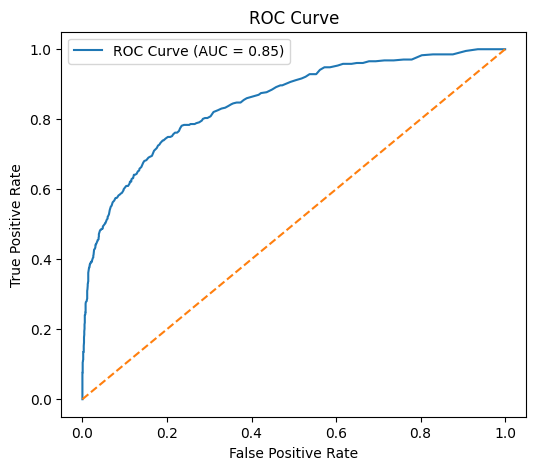

           Feature  Importance
3              Age    0.240214
9  EstimatedSalary    0.147265
0      CreditScore    0.144280
5          Balance    0.140926
6    NumOfProducts    0.130197
4           Tenure    0.081067
8   IsActiveMember    0.039724
1        Geography    0.038104
7        HasCrCard    0.019550
2           Gender    0.018674


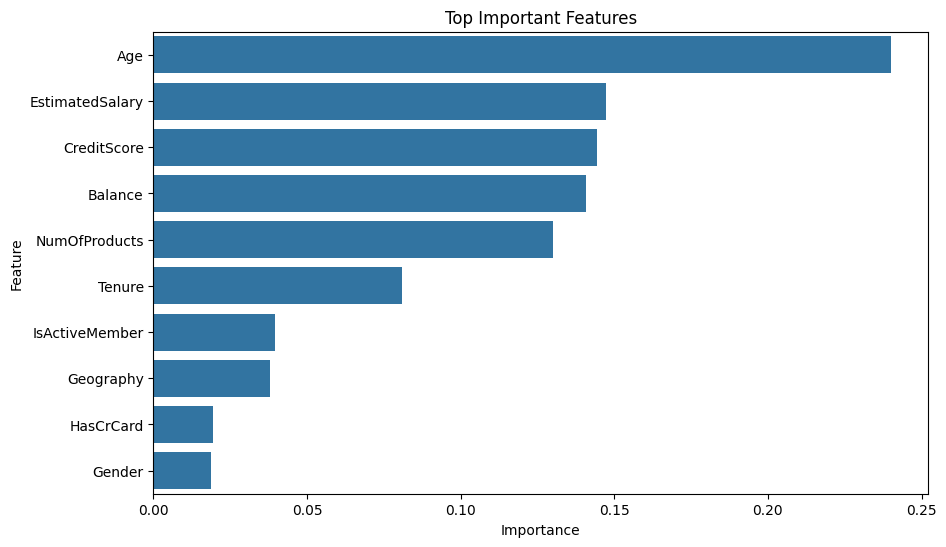

XGBoost Accuracy: 0.8675


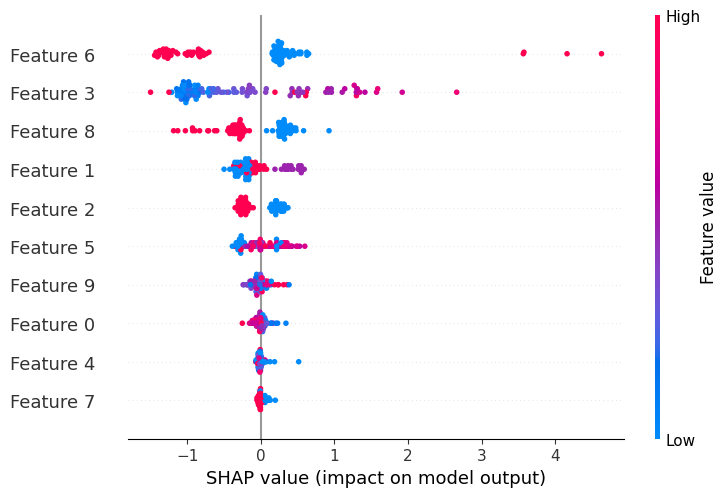

   Churn Probability Risk Level
0           0.018884   Low Risk
1           0.077325   Low Risk
2           0.036248   Low Risk
3           0.055045   Low Risk
4           0.105673   Low Risk
---------- SAMPLE CUSTOMER PREDICTIONS ----------
Prediction: Customer Will Stay
Churn Probability: 0.17668892
Prediction: Customer Will Stay
Churn Probability: 0.08671696

Business Insights:

1. Customers with fewer products
   are more likely to churn.

2. Active members are less likely
   to leave the company.

3. High-risk customers can be
   targeted with retention offers.

4. The prediction system helps
   companies reduce customer loss.

Advanced Customer Churn Prediction Completed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
!pip install xgboost shap wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os

from wordcloud import WordCloud

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print(os.listdir())

file_name = "Churn_Modelling.csv"

customer_data = pd.read_csv(file_name)

print(customer_data.head())

print(customer_data.shape)

print(customer_data.columns)

print(customer_data.isnull().sum())

print(customer_data["Exited"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x="Exited",
    data=customer_data
)

plt.title("Customer Churn Count")

plt.show()

plt.figure(figsize=(12,8))

sns.heatmap(
    customer_data.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

customer_data = customer_data.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

geo_encoder = LabelEncoder()

gender_encoder = LabelEncoder()

customer_data["Geography"] = geo_encoder.fit_transform(
    customer_data["Geography"]
)

customer_data["Gender"] = gender_encoder.fit_transform(
    customer_data["Gender"]
)

print(customer_data.head())

X = customer_data.drop("Exited", axis=1)

y = customer_data["Exited"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True
    )
}

results = {}

predictions = {}

for model_name, model in models.items():

    print("Training:", model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    predictions[model_name] = y_pred

    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1 Score:", f1)

    print(classification_report(y_test, y_pred))

comparison_df = pd.DataFrame(results).T

print(comparison_df)

comparison_df.to_csv(
    "advanced_customer_churn_model_comparison.csv"
)

best_model_name = comparison_df["Accuracy"].idxmax()

best_model = models[best_model_name]

best_prediction = predictions[best_model_name]

print(best_model_name)

print(comparison_df.loc[best_model_name, "Accuracy"])

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df.index,
    comparison_df["Accuracy"]
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Customer Churn Prediction Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

comparison_df[
    ["Precision", "Recall", "F1 Score"]
].plot(kind="bar", figsize=(9,5))

plt.title("Precision Recall and F1 Score")

plt.xticks(rotation=20)

plt.show()

cm = confusion_matrix(
    y_test,
    best_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="ROC Curve (AUC = %0.2f)" % roc_auc
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top Important Features")

plt.show()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_test[:100])

shap.plots.beeswarm(shap_values)

probabilities = best_xgb.predict_proba(X_test)[:,1]

risk_level = []

for prob in probabilities:

    if prob > 0.7:
        risk_level.append("High Risk")

    elif prob > 0.4:
        risk_level.append("Medium Risk")

    else:
        risk_level.append("Low Risk")

risk_df = pd.DataFrame({
    "Churn Probability": probabilities,
    "Risk Level": risk_level
})

print(risk_df.head())

risk_df.to_csv(
    "customer_risk_levels.csv",
    index=False
)

prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred
})

prediction_results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

def predict_customer_churn(
    credit_score,
    geography,
    gender,
    age,
    tenure,
    balance,
    products,
    has_credit_card,
    is_active_member,
    estimated_salary
):

    geography = geo_encoder.transform([geography])[0]

    gender = gender_encoder.transform([gender])[0]

    input_data = np.array([[
        credit_score,
        geography,
        gender,
        age,
        tenure,
        balance,
        products,
        has_credit_card,
        is_active_member,
        estimated_salary
    ]])

    scaled_data = scaler.transform(input_data)

    prediction = best_xgb.predict(scaled_data)[0]

    probability = best_xgb.predict_proba(
        scaled_data
    )[0][1]

    if prediction == 1:
        result = "Customer Will Leave"
    else:
        result = "Customer Will Stay"

    print("Prediction:", result)

    print("Churn Probability:", probability)

print("---------- SAMPLE CUSTOMER PREDICTIONS ----------")

predict_customer_churn(
    650,
    "France",
    "Female",
    45,
    5,
    120000,
    2,
    1,
    1,
    50000
)

predict_customer_churn(
    750,
    "Germany",
    "Male",
    30,
    7,
    50000,
    1,
    1,
    1,
    90000
)

joblib.dump(
    best_xgb,
    "advanced_customer_churn_model.pkl"
)

joblib.dump(
    scaler,
    "customer_churn_scaler.pkl"
)

print("""
Business Insights:

1. Customers with fewer products
   are more likely to churn.

2. Active members are less likely
   to leave the company.

3. High-risk customers can be
   targeted with retention offers.

4. The prediction system helps
   companies reduce customer loss.
""")

print("Advanced Customer Churn Prediction Completed")